In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
#import statmodels.api as sm
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/housing/target.csv
/kaggle/input/housing/train.csv
/kaggle/input/housing/test.csv
/kaggle/input/housing/AmesHousing.csv


In [2]:
#train_df = pd.read_csv('/kaggle/input/housing/train.csv')
#target_df = pd.read_csv('/kaggle/input/housing/target.csv')
#test_df = pd.read_csv('/kaggle/input/housing/target.csv')
ames_df = pd.read_csv('/kaggle/input/housing/AmesHousing.csv')

In [3]:
ames_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 82 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Order            2930 non-null   int64  
 1   PID              2930 non-null   int64  
 2   MS SubClass      2930 non-null   int64  
 3   MS Zoning        2930 non-null   object 
 4   Lot Frontage     2440 non-null   float64
 5   Lot Area         2930 non-null   int64  
 6   Street           2930 non-null   object 
 7   Alley            198 non-null    object 
 8   Lot Shape        2930 non-null   object 
 9   Land Contour     2930 non-null   object 
 10  Utilities        2930 non-null   object 
 11  Lot Config       2930 non-null   object 
 12  Land Slope       2930 non-null   object 
 13  Neighborhood     2930 non-null   object 
 14  Condition 1      2930 non-null   object 
 15  Condition 2      2930 non-null   object 
 16  Bldg Type        2930 non-null   object 
 17  House Style   

In [4]:
ames_df.describe()

,Order,PID,MS SubClass,Lot Frontage,Lot Area,Overall Qual,Overall Cond,Year Built,Year Remod/Add,Mas Vnr Area,...,Wood Deck SF,Open Porch SF,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Misc Val,Mo Sold,Yr Sold,SalePrice
count,2930.00000,2.930000e+03,2930.000000,2440.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2907.000000,...,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000
mean,1465.50000,7.144645e+08,57.387372,69.224590,10147.921843,6.094881,5.563140,1971.356314,1984.266553,101.896801,...,93.751877,47.533447,23.011604,2.592491,16.002048,2.243345,50.635154,6.216041,2007.790444,180796.060068
std,845.96247,1.887308e+08,42.638025,23.365335,7880.017759,1.411026,1.111537,30.245361,20.860286,179.112611,...,126.361562,67.483400,64.139059,25.141331,56.087370,35.597181,566.344288,2.714492,1.316613,79886.692357
min,1.00000,5.263011e+08,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,12789.000000
25%,733.25000,5.284770e+08,20.000000,58.000000,7440.250000,5.000000,5.000000,1954.000000,1965.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000,2007.000000,129500.000000
50%,1465.50000,5.354536e+08,50.000000,68.000000,9436.500000,6.000000,5.000000,1973.000000,1993.000000,0.000000,...,0.000000,27.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,160000.000000
75%,2197.75000,9.071811e+08,70.000000,80.000000,11555.250000,7.000000,6.000000,2001.000000,2004.000000,164.000000,...,168.000000,70.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,213500.000000
max,2930.00000,1.007100e+09,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,...,1424.000000,742.000000,1012.000000,508.000000,576.000000,800.000000,17000.000000,12.000000,2010.000000,755000.000000


There are 81 variables, it would not be feasible to analyze every single variable.
However, we can start analyzing the variables that are widely assumed to influence housing prices: Lot size (Lot Area), Grand living area (Gr Liv Area) aka total square footage, number of bedrooms (Bedroom AbvGr), number of bathrooms (Full Bath), Garage (Garage Cars).

Plotting pairplot of the variables that we have selected.

In [5]:
df = ames_df[['Gr Liv Area', 'Lot Area', 'Bedroom AbvGr', 'Full Bath', 'Garage Cars', 'SalePrice']]
#indep_vars = train_df[['Lot Area', 'Bedroom AbvGr', 'Full Bath', 'Garage Cars']]

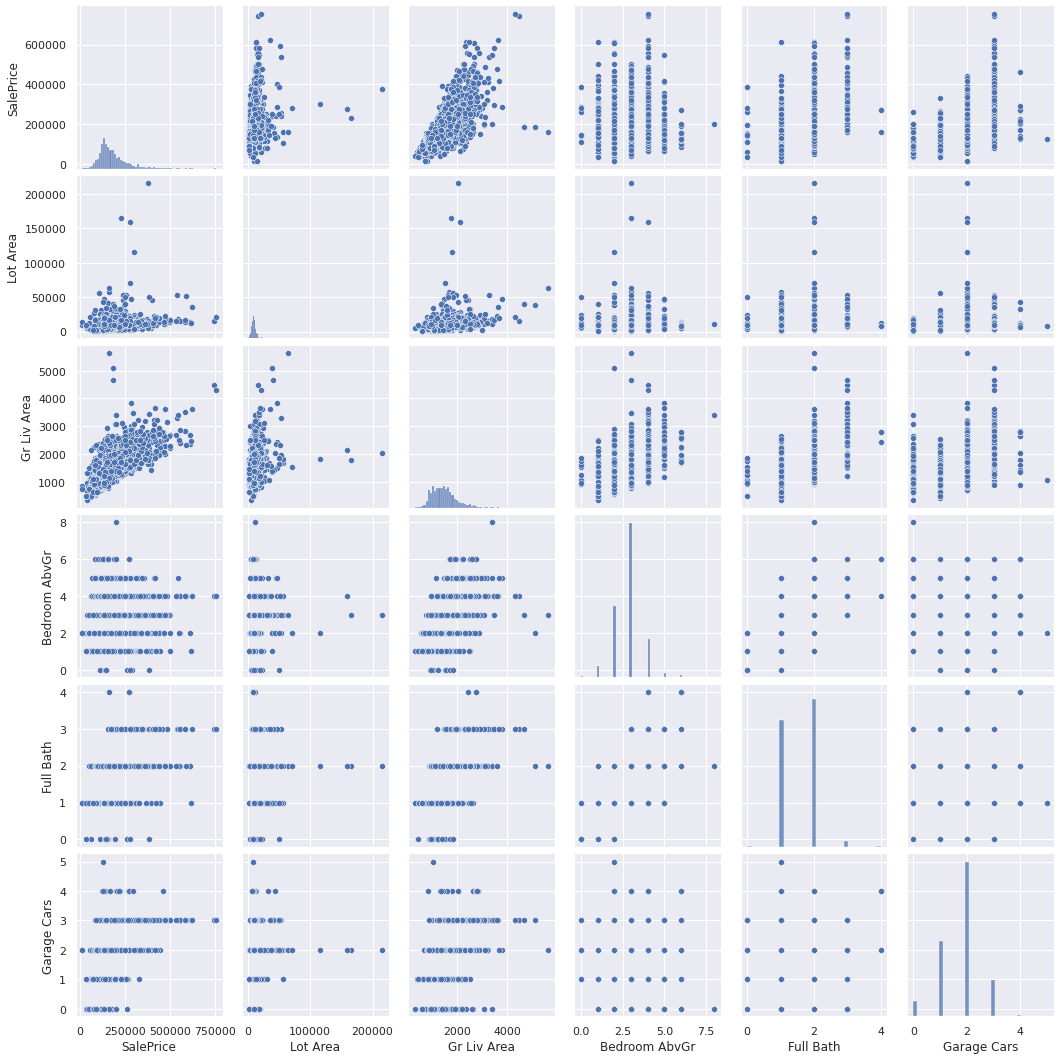

In [6]:
sns.set()
cols = ['SalePrice', 'Lot Area', 'Gr Liv Area', 'Bedroom AbvGr', 'Full Bath', 'Garage Cars']
sns.pairplot(ames_df[cols], height = 2.5)
plt.show();

## Checking for NaN values for the variables that we have selected.

<AxesSubplot:>

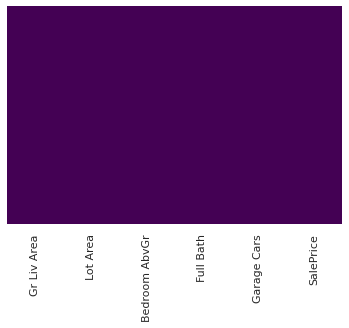

In [7]:
sns.heatmap(df.isnull(),yticklabels=False,cbar=False,cmap='viridis')

From .info() it appears that there's one missing value in one of the variables ("Garage Cars") that we have selected. 

In [8]:
garage_mean = df['Garage Cars'].mean()

In [9]:
df['Garage Cars'].fillna(value=garage_mean, inplace = True)

/opt/conda/lib/python3.7/site-packages/pandas/core/generic.py:6392: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  return self._update_inplace(result)


In [10]:
ames_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 82 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Order            2930 non-null   int64  
 1   PID              2930 non-null   int64  
 2   MS SubClass      2930 non-null   int64  
 3   MS Zoning        2930 non-null   object 
 4   Lot Frontage     2440 non-null   float64
 5   Lot Area         2930 non-null   int64  
 6   Street           2930 non-null   object 
 7   Alley            198 non-null    object 
 8   Lot Shape        2930 non-null   object 
 9   Land Contour     2930 non-null   object 
 10  Utilities        2930 non-null   object 
 11  Lot Config       2930 non-null   object 
 12  Land Slope       2930 non-null   object 
 13  Neighborhood     2930 non-null   object 
 14  Condition 1      2930 non-null   object 
 15  Condition 2      2930 non-null   object 
 16  Bldg Type        2930 non-null   object 
 17  House Style   

"Gr Liv Area" (or total square footage) has a quadratic relationship with SalePrice. We may want to introduce a quadratic (squaring "Gr Liv Area") term in out model to reflect this relationship.

In [11]:
df['sqfoot_sq'] = df['Gr Liv Area']**2

/opt/conda/lib/python3.7/site-packages/ipykernel_launcher.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  """Entry point for launching an IPython kernel.


In [12]:
df.head()

,Gr Liv Area,Lot Area,Bedroom AbvGr,Full Bath,Garage Cars,SalePrice,sqfoot_sq
0,1656,31770,3,1,2.0,215000,2742336
1,896,11622,2,1,1.0,105000,802816
2,1329,14267,3,1,1.0,172000,1766241
3,2110,11160,3,2,2.0,244000,4452100
4,1629,13830,3,2,2.0,189900,2653641


## Plotting correlation matrix

Create a correlogram/heatmap to check to see if there's any possible correlation among the variables selected. If there's a high correlation between two variables, this can cause multi-collinearity which could adversely affect the performance of our regression model.

<AxesSubplot:>

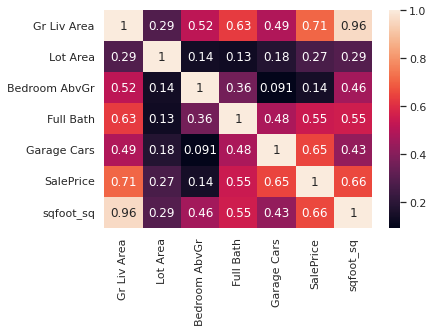

In [13]:
sns.heatmap(df.corr(),annot=True)

From the correlation matrix, 3 of the 4 (Gr Liv Area, Full Bath and Garage Cars) independent variables are strongly positively correlated with SalePrice. Surprisingly, Bedroom AbvGr (bedrooms that are in the main living area of house (not in basement)) and Lot Area have a weak correlation with SalePrice. We can consider omitting Bedroom AbvGr and Lot Area in our model.

In [14]:
df = df.drop(['Bedroom AbvGr','Lot Area'], axis=1)

In [15]:
df.columns

Index(['Gr Liv Area', 'Full Bath', 'Garage Cars', 'SalePrice', 'sqfoot_sq'], dtype='object')

Let's do a variance inflation factor (VIF) test for multicollinearity. We want to avoid multicollinearity because it would adversely affect the precision of our model. https://en.wikipedia.org/wiki/Multicollinearityhttps://en.wikipedia.org/wiki/Multicollinearity

In [16]:
#From Statology: https://www.statology.org/multicollinearity-in-python/
from patsy import dmatrices
from statsmodels.stats.outliers_influence import variance_inflation_factor

#putting the independent variables in a list
indep_vars = df[['Full Bath', 'Garage Cars', 'sqfoot_sq']]

#find design matrix for regression model using 'rating' as response variable 
y, X = dmatrices('SalePrice ~ indep_vars', data=df, return_type='dataframe')

#create DataFrame to hold VIF values
vif_df = pd.DataFrame()
vif_df['variable'] = X.columns 

#calculate VIF for each predictor variable 
vif_df['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

#view VIF for each predictor variable 
print(vif_df)


        variable        VIF
0      Intercept  10.584139
1  indep_vars[0]   1.609670
2  indep_vars[1]   1.363799
3  indep_vars[2]   1.519750


Since each of the VIF values for the independent variables that we selected are between 1.0 and 2.4, there is an appearance of multicollinearity among the independent variable but not severe enough for us to omit them.

## What about the categorical variables in the data?

We may be doing ourselves a disservice if we don't consider non-numeric or categorical variables that could influence SalePrice. 

There are several categorical variables to consider. However, we may only want to select either 2 or 3 that may have an effect on Sale Price. We can conduct research online on what features of a home may affect Sale Price. After conducting research, we found that the following features tend to have an effect on SalePrice:

- Neighborhood ("Neighborhood")
- Condition of the home ("Overall Cond") - this is a numeric variable, perhaps a rating? (need to look into this)
- Whether the home was renovated ("Year Remod/Add")
- Kitchen Quality ("Kitchen Qual")


Let's examine the relationship of these variables with SalePrice. Before we conduct our analyses, we are going to have to transform these variables.

In [17]:
cat_vars = ames_df[["Neighborhood","Overall Cond","Year Remod/Add","Kitchen Qual","Lot Config"]]

In [18]:
for i in cat_vars:
    df[i] = cat_vars[i].astype('category')
    

In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   Gr Liv Area     2930 non-null   int64   
 1   Full Bath       2930 non-null   int64   
 2   Garage Cars     2930 non-null   float64 
 3   SalePrice       2930 non-null   int64   
 4   sqfoot_sq       2930 non-null   int64   
 5   Neighborhood    2930 non-null   category
 6   Overall Cond    2930 non-null   category
 7   Year Remod/Add  2930 non-null   category
 8   Kitchen Qual    2930 non-null   category
 9   Lot Config      2930 non-null   category
dtypes: category(5), float64(1), int64(4)
memory usage: 133.5 KB


## We've transformed our categorical variables, let's take a look how these relate to SalePrice.

Let's see whether homes in certain neighborhoods are more valuable, in terms of SalePrice, are more valuable than others.

In [21]:
df1 = df

In [22]:
df1["Neighborhood"] = ames_df["Neighborhood"].astype('category')
df1["hood_cat"] = df1["Neighborhood"].cat.codes

/opt/conda/lib/python3.7/site-packages/seaborn/categorical.py:1296: UserWarning: 67.9% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/opt/conda/lib/python3.7/site-packages/seaborn/categorical.py:1296: UserWarning: 40.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/opt/conda/lib/python3.7/site-packages/seaborn/categorical.py:1296: UserWarning: 83.3% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/opt/conda/lib/python3.7/site-packages/seaborn/categorical.py:1296: UserWarning: 86.1% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/opt/conda/lib/python3.7/site-packages/seaborn/categorical.py:1296: UserWarning: 56.8% of the points cannot be placed; y

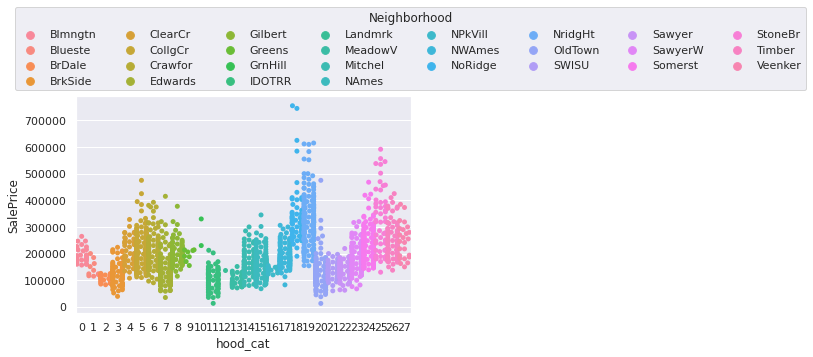

In [23]:
ax = sns.swarmplot(data=df1, x="hood_cat", y="SalePrice", hue = "Neighborhood")
#plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0)
sns.move_legend(ax, "lower center", bbox_to_anchor=(1, 1), ncol = 8)

The swarmplot shows that there are some neighborhoods that are more desirable than others based on the distribution of the sale prices. We can discern that neighborhood can influence sale price.

<AxesSubplot:xlabel='Overall Cond', ylabel='SalePrice'>

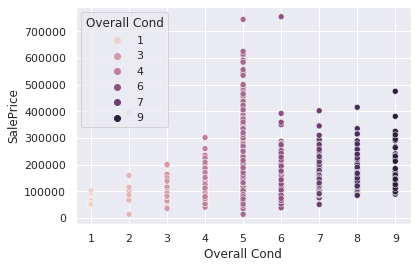

In [24]:
#fig, ax = plt.subplots(3,1)
#sns.scatterplot(data=df,x="kitchen_qual",y="SalePrice", ax=ax[0])
#sns.scatterplot(data=df,x='condition',y='SalePrice', ax=ax[1])
#sns.scatterplot(data=df,x='year_remod_add',y='SalePrice', ax=ax[2])

#sns.scatterplot(data=ames_df,x="Kitchen Qual",y="SalePrice", hue="Kitchen Qual", ax=ax[0])
sns.scatterplot(data=ames_df,x="Overall Cond",y="SalePrice", hue="Overall Cond")


There's a positive relationship between condition and sale price. This plot shows that homes with a higher overall condition rating tend to yield a higher sales price.

<AxesSubplot:xlabel='Year Remod/Add', ylabel='SalePrice'>

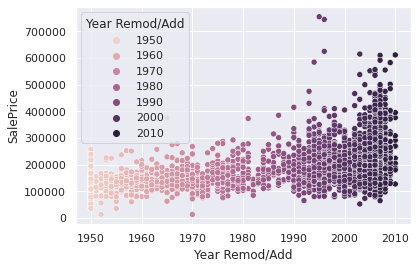

In [25]:
sns.scatterplot(data=ames_df,x="Year Remod/Add",y="SalePrice", hue="Year Remod/Add")


This plot shows that homes that undergone more recent remodel and additions tend to yield a higher sales price.

<AxesSubplot:xlabel='Kitchen Qual', ylabel='SalePrice'>

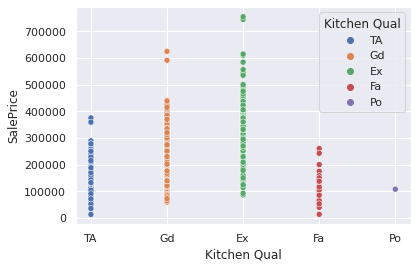

In [26]:
sns.scatterplot(data=ames_df,x="Kitchen Qual",y="SalePrice", hue="Kitchen Qual")

This plot shows that homes that have kitchen quality rated as "Good" or "Excellent" and additions tend to yield a higher sales price.

We're going to "hot-encode" the categorical variables we've selected.





<AxesSubplot:xlabel='Lot Config', ylabel='SalePrice'>

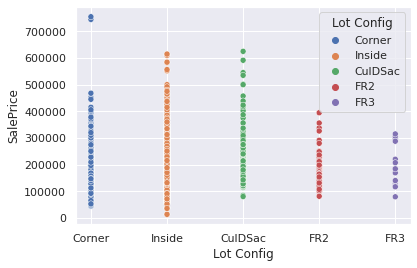

In [27]:
sns.scatterplot(data=ames_df,x="Lot Config",y="SalePrice", hue="Lot Config")

In [28]:
neighborhood = pd.get_dummies(df['Neighborhood'],drop_first=True)
condition = pd.get_dummies(df['Overall Cond'],drop_first=True)
year_remod_add = pd.get_dummies(df['Year Remod/Add'],drop_first=True)
kitchen_qual = pd.get_dummies(df['Kitchen Qual'],drop_first=True)
#lot_config = pd.get_dummies(df['Lot Config'],drop_first=True)

In [29]:
df = pd.concat([df,neighborhood,condition,year_remod_add,kitchen_qual],axis=1)

In [30]:
df.columns

Index([   'Gr Liv Area',      'Full Bath',    'Garage Cars',      'SalePrice',
            'sqfoot_sq',   'Neighborhood',   'Overall Cond', 'Year Remod/Add',
         'Kitchen Qual',     'Lot Config',
       ...
                   2005,             2006,             2007,             2008,
                   2009,             2010,             'Fa',             'Gd',
                   'Po',             'TA'],
      dtype='object', length=110)

In [31]:
df = df.drop(['Neighborhood','Overall Cond','Year Remod/Add','Kitchen Qual','Lot Config'],axis = 1)

In [38]:
df = df.drop('Lot Config',axis = 1)

In [32]:
df.columns

Index(['Gr Liv Area',   'Full Bath', 'Garage Cars',   'SalePrice',
         'sqfoot_sq',  'Lot Config',    'hood_cat',     'Blueste',
            'BrDale',     'BrkSide',
       ...
                2005,          2006,          2007,          2008,
                2009,          2010,          'Fa',          'Gd',
                'Po',          'TA'],
      dtype='object', length=106)

So, we've encoded neighborhood, and variables with date/time features. Next, we're going transform ratings variables: kitchen quality and overall condition of the house. Let's take a look at the distribution of these rating variables.

In [33]:
df.head()

,Gr Liv Area,Full Bath,Garage Cars,SalePrice,sqfoot_sq,Lot Config,hood_cat,Blueste,BrDale,BrkSide,...,2005,2006,2007,2008,2009,2010,Fa,Gd,Po,TA
0,1656,1,2.0,215000,2742336,Corner,15,0,0,0,...,0,0,0,0,0,0,0,0,0,1
1,896,1,1.0,105000,802816,Inside,15,0,0,0,...,0,0,0,0,0,0,0,0,0,1
2,1329,1,1.0,172000,1766241,Corner,15,0,0,0,...,0,0,0,0,0,0,0,1,0,0
3,2110,2,2.0,244000,4452100,Corner,15,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,1629,2,2.0,189900,2653641,Inside,8,0,0,0,...,0,0,0,0,0,0,0,0,0,1


## Let's take a look at the distribution of sale price.

In [ ]:
plt.hist(df['SalePrice'])
plt.title('Sale Price')
plt.show()

In [ ]:
#pd.set_option('display.max_columns', 84)

In [ ]:
#sns.catplot(
#    data=ames_df, x="Mo Sold", y="SalePrice",
#   col="Yr Sold",
#    kind="swarm")

In [ ]:
#sns.catplot(
#    data=ames_df, x="Mo Sold", y="SalePrice",
#   col="Yr Sold",
#    kind="swarm")

It appears that seasonality in home sales should not have an impact on the precision of our model.

## Let's build some models...

### Let's start with a basic OLS regression model

First, let's do a train-test split of the independent variables selected (var_group1): X, and the dependent or target variable (SalePrice): y.

In [34]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [39]:
df.columns

Index(['Gr Liv Area',   'Full Bath', 'Garage Cars',   'SalePrice',
         'sqfoot_sq',    'hood_cat',     'Blueste',      'BrDale',
           'BrkSide',     'ClearCr',
       ...
                2005,          2006,          2007,          2008,
                2009,          2010,          'Fa',          'Gd',
                'Po',          'TA'],
      dtype='object', length=105)

In [40]:
#X = df.drop(['SalePrice','Bedroom AbvGr'],axis=1)
X = df.drop('SalePrice',axis=1)
y = df[['SalePrice']]

Use model_selection.train_test_split from sklearn to split the data into training and testing sets. Set test_size=0.3 and random_state=101.

In [41]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=101)

Creating an instance of a LinearRegression() model named lm.

In [42]:
lm = LinearRegression()

First, we fit the model to the training data.

In [43]:
lm.fit(X_train, y_train)

/opt/conda/lib/python3.7/site-packages/sklearn/utils/validation.py:1692: FutureWarning: Feature names only support names that are all strings. Got feature names with dtypes: ['int', 'str']. An error will be raised in 1.2.
  FutureWarning,


LinearRegression()

Printing the intercept value.

In [44]:
print(lm.intercept_)

[91182.03435684]


Printing the coefficients.

In [45]:
print(lm.coef_)

[[ 4.07859938e+01 -2.64263688e+03  1.45051002e+04  7.06981933e-03
   6.83258727e+02 -1.94364388e+04 -3.08025979e+04 -2.18798631e+04
   1.58491371e+04  6.13480429e+03  1.28959395e+04 -2.73757135e+04
  -5.95167373e+03  2.70592336e+04  1.12111061e+05 -3.85100633e+04
  -2.20324655e+04 -3.91877396e+04 -1.10002633e+04 -2.40753930e+04
  -2.26819893e+04 -1.16014175e+04  4.96666650e+04  3.97036968e+04
  -5.28480909e+04 -3.56220955e+04 -2.94744246e+04 -1.66533019e+04
  -9.48946230e+02  6.57704498e+04  8.23047646e+03  1.76247901e+04
  -2.01369544e+03  7.31623105e+03  2.00100273e+04  3.83597926e+04
   4.18913749e+04  4.28266912e+04  4.47070255e+04  4.42286575e+04
  -9.12062128e+03 -1.72997475e+03  6.53167870e+03  6.06759201e+03
   4.39821123e+03  1.15656516e+04  1.49441379e+04  5.94883301e+03
   1.32231684e+04  1.04689670e+04  1.49539996e+04  1.24177745e+04
   1.37369412e+04  1.07853533e+04  1.53379735e+04  2.01211936e+04
   1.37864590e+04  1.01815708e+04  1.63105147e+03  4.56405024e+03
   8.17414

Creating dataframe of coefficients.

In [ ]:
#cdf_lm = pd.DataFrame(lm.coef_, X.columns, columns=['Coeff'])

### Let's predict the results with the OLS model

In [46]:
predictions = lm.predict(X_test)

/opt/conda/lib/python3.7/site-packages/sklearn/utils/validation.py:1692: FutureWarning: Feature names only support names that are all strings. Got feature names with dtypes: ['int', 'str']. An error will be raised in 1.2.
  FutureWarning,


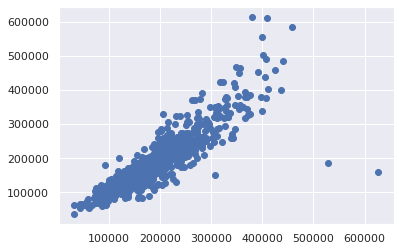

In [47]:
plt.scatter(predictions, y_test)

In [51]:
from sklearn import metrics
#from sklearn.metrics

In [52]:
MAE = metrics.mean_absolute_error(y_test, predictions)
MSE = metrics.mean_squared_error(y_test, predictions)
RSME = np.sqrt(MSE)

print(MAE, MSE, RSME)

23551.78271914101 1465620706.1737075 38283.42599838352


## Residuals

/opt/conda/lib/python3.7/site-packages/seaborn/distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


<AxesSubplot:ylabel='Density'>

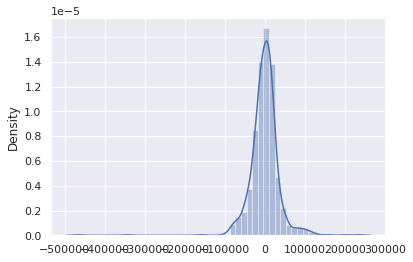

In [48]:
sns.distplot(y_test-predictions)

Pretty normal distribution (density centered around 0) of the residuals which indicates that our linear regression model is good model to use.

In [49]:
#cdf = pd.DataFrame(lm.coef_, X.columns, columns=['Coefficient'])
#cdf

ValueError: Shape of passed values is (1, 104), indices imply (104, 1)

In [56]:
pd.set_option('display.max_rows', None)

In [57]:
#pd.DataFrame(zip(X.columns, lm.coef_))
coefficients = pd.concat([pd.DataFrame(X.columns),pd.DataFrame(np.transpose(lm.coef_))], axis = 1)
print(coefficients)

               0              0
0    Gr Liv Area      40.785994
1      Full Bath   -2642.636883
2    Garage Cars   14505.100178
3      sqfoot_sq       0.007070
4       hood_cat     683.258727
5        Blueste  -19436.438768
6         BrDale  -30802.597881
7        BrkSide  -21879.863055
8        ClearCr   15849.137140
9        CollgCr    6134.804289
10       Crawfor   12895.939533
11       Edwards  -27375.713517
12       Gilbert   -5951.673725
13        Greens   27059.233604
14       GrnHill  112111.060655
15        IDOTRR  -38510.063256
16       Landmrk  -22032.465540
17       MeadowV  -39187.739555
18       Mitchel  -11000.263314
19         NAmes  -24075.393044
20       NPkVill  -22681.989322
21        NWAmes  -11601.417478
22       NoRidge   49666.664954
23       NridgHt   39703.696841
24       OldTown  -52848.090927
25         SWISU  -35622.095525
26        Sawyer  -29474.424592
27       SawyerW  -16653.301924
28       Somerst    -948.946230
29       StoneBr   65770.449786
30      

In [ ]:
#from sklearn.metrics import classification_report

In [ ]:
def regression_results(y_test, predictions):

    # Regression metrics
    explained_variance=metrics.explained_variance_score(y_test, predictions)
    mean_absolute_error=metrics.mean_absolute_error(y_test, predictions) 
    mse=metrics.mean_squared_error(y_test, predictions) 
    mean_squared_log_error=metrics.mean_squared_log_error(y_test, predictions)
    median_absolute_error=metrics.median_absolute_error(y_test, predictions)
    r2=metrics.r2_score(y_test, predictions)

    print('explained_variance: ', round(explained_variance,4))    
    print('mean_squared_log_error: ', round(mean_squared_log_error,4))
    print('r2: ', round(r2,4))
    print('MAE: ', round(mean_absolute_error,4))
    print('MSE: ', round(mse,4))
    print('RMSE: ', round(np.sqrt(mse),4))

In [53]:
# Regression metrics
explained_variance=metrics.explained_variance_score(y_test, predictions)
mean_absolute_error=metrics.mean_absolute_error(y_test, predictions) 
mse=metrics.mean_squared_error(y_test, predictions) 
mean_squared_log_error=metrics.mean_squared_log_error(y_test, predictions)
median_absolute_error=metrics.median_absolute_error(y_test, predictions)
r2=metrics.r2_score(y_test, predictions)

print('explained_variance: ', round(explained_variance,4))    
print('mean_squared_log_error: ', round(mean_squared_log_error,4))
print('r2: ', round(r2,4))
print('MAE: ', round(mean_absolute_error,4))
print('MSE: ', round(mse,4))
print('RMSE: ', round(np.sqrt(mse),4))

explained_variance:  0.7681
mean_squared_log_error:  0.0315
r2:  0.768
MAE:  23551.7827
MSE:  1465620706.1737
RMSE:  38283.426


In [54]:
print(lm.coef_)

[[ 4.07859938e+01 -2.64263688e+03  1.45051002e+04  7.06981933e-03
   6.83258727e+02 -1.94364388e+04 -3.08025979e+04 -2.18798631e+04
   1.58491371e+04  6.13480429e+03  1.28959395e+04 -2.73757135e+04
  -5.95167373e+03  2.70592336e+04  1.12111061e+05 -3.85100633e+04
  -2.20324655e+04 -3.91877396e+04 -1.10002633e+04 -2.40753930e+04
  -2.26819893e+04 -1.16014175e+04  4.96666650e+04  3.97036968e+04
  -5.28480909e+04 -3.56220955e+04 -2.94744246e+04 -1.66533019e+04
  -9.48946230e+02  6.57704498e+04  8.23047646e+03  1.76247901e+04
  -2.01369544e+03  7.31623105e+03  2.00100273e+04  3.83597926e+04
   4.18913749e+04  4.28266912e+04  4.47070255e+04  4.42286575e+04
  -9.12062128e+03 -1.72997475e+03  6.53167870e+03  6.06759201e+03
   4.39821123e+03  1.15656516e+04  1.49441379e+04  5.94883301e+03
   1.32231684e+04  1.04689670e+04  1.49539996e+04  1.24177745e+04
   1.37369412e+04  1.07853533e+04  1.53379735e+04  2.01211936e+04
   1.37864590e+04  1.01815708e+04  1.63105147e+03  4.56405024e+03
   8.17414

## Linear regression without the quadratic term for square footage

In [59]:
X2 = df.drop(['SalePrice','sqfoot_sq'],axis=1)
y2 = df[['SalePrice']]

In [60]:
X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2, test_size=0.3, random_state=101)

In [61]:
lm2 = LinearRegression()

In [62]:
lm2.fit(X2_train, y2_train)

/opt/conda/lib/python3.7/site-packages/sklearn/utils/validation.py:1692: FutureWarning: Feature names only support names that are all strings. Got feature names with dtypes: ['int', 'str']. An error will be raised in 1.2.
  FutureWarning,


LinearRegression()

In [63]:
print(lm2.intercept_)

[71202.50063075]


In [65]:
predictions2 = lm2.predict(X2_test)

/opt/conda/lib/python3.7/site-packages/sklearn/utils/validation.py:1692: FutureWarning: Feature names only support names that are all strings. Got feature names with dtypes: ['int', 'str']. An error will be raised in 1.2.
  FutureWarning,


In [66]:
MAE = metrics.mean_absolute_error(y2_test, predictions2)
MSE = metrics.mean_squared_error(y2_test, predictions2)
RSME = np.sqrt(MSE)

print(MAE, MSE, RSME)

23604.40873261983 1349677151.037182 36737.95246114272


/opt/conda/lib/python3.7/site-packages/seaborn/distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


<AxesSubplot:ylabel='Density'>

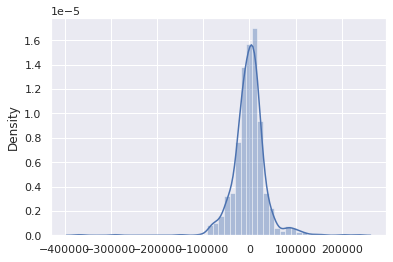

In [67]:
sns.distplot(y2_test-predictions2)


In [68]:
coefficients2 = pd.concat([pd.DataFrame(X.columns),pd.DataFrame(np.transpose(lm2.coef_))], axis = 1)
print(coefficients2)

               0              0
0    Gr Liv Area      66.788074
1      Full Bath   -3196.894450
2    Garage Cars   14266.294931
3      sqfoot_sq     683.379377
4       hood_cat  -18389.658921
5        Blueste  -30832.760964
6         BrDale  -21586.257704
7        BrkSide   14831.304715
8        ClearCr    6092.915714
9        CollgCr   11209.367644
10       Crawfor  -26277.324325
11       Edwards   -6716.358260
12       Gilbert   28350.539808
13        Greens  111935.367145
14       GrnHill  -37710.776004
15        IDOTRR  -21731.214812
16       Landmrk  -38480.912136
17       MeadowV  -10510.659796
18       Mitchel  -23864.171088
19         NAmes  -22110.386480
20       NPkVill  -12661.373250
21        NWAmes   53252.495628
22       NoRidge   38519.211485
23       NridgHt  -52931.196904
24       OldTown  -36250.432699
25         SWISU  -28556.310540
26        Sawyer  -16405.754559
27       SawyerW   -1501.728874
28       Somerst   66077.912446
29       StoneBr    7365.345103
30      

In [69]:
# Regression metrics
explained_variance=metrics.explained_variance_score(y2_test, predictions2)
mean_absolute_error=metrics.mean_absolute_error(y2_test, predictions2) 
mse=metrics.mean_squared_error(y2_test, predictions2) 
mean_squared_log_error=metrics.mean_squared_log_error(y2_test, predictions2)
median_absolute_error=metrics.median_absolute_error(y2_test, predictions2)
r2=metrics.r2_score(y2_test, predictions2)

print('explained_variance: ', round(explained_variance,4))    
print('mean_squared_log_error: ', round(mean_squared_log_error,4))
print('r2: ', round(r2,4))
print('MAE: ', round(mean_absolute_error,4))
print('MSE: ', round(mse,4))
print('RMSE: ', round(np.sqrt(mse),4))

explained_variance:  0.7864
mean_squared_log_error:  0.0327
r2:  0.7864
MAE:  23604.4087
MSE:  1349677151.0372
RMSE:  36737.9525


In this regression without the square footage quadratic term, r-squared slightly increased, however, the MSLE, MAE, MSE, and RMSE slightlyn increased. Due to the increase in errors, we should opt to use the regression with the square footage quadratic term.